In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import itertools
import community as community_louvain
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set path for real graphs
directory = 'dblp/real/'

In [3]:
# Set path for output motifs
path = 'dblp/motifs/'

In [4]:
author_node_type = 1

In [5]:
def plot_graph(G):

    color_class_map = {0: 'blue', 1: 'red', 2: 'darkgreen', 3: 'orange'}

    nx.draw(G, 
        with_labels=False, node_color=[color_class_map[node[1]['type']] 
                        for node in G.nodes(data=True)], 
            node_size=200,
        font_color='white')
    plt.show() 

author_node_classes [0]
original graph


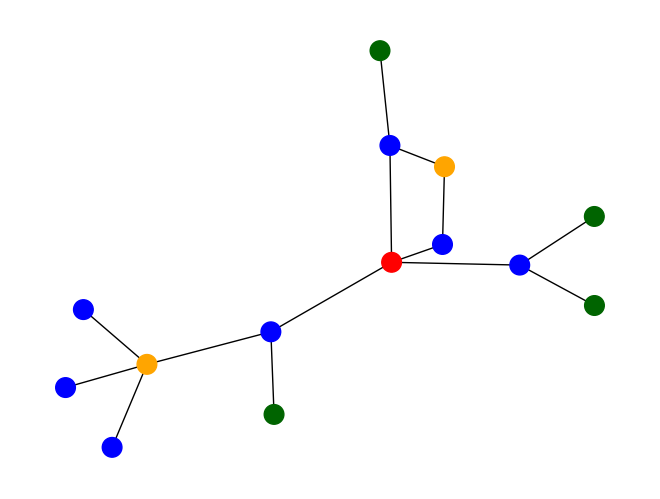

motif


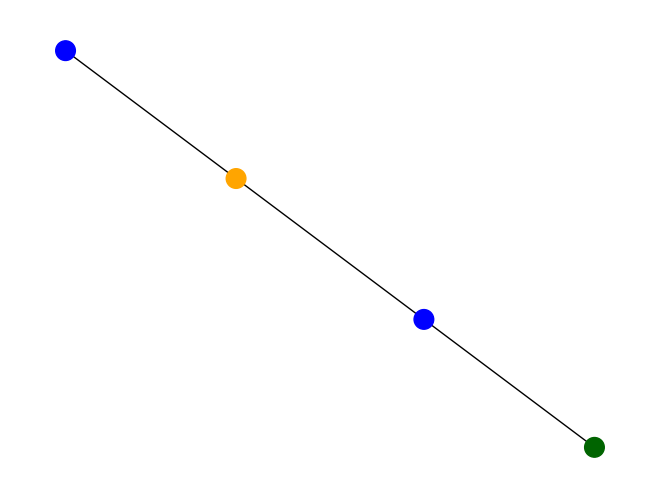

author_node_classes [0]
original graph


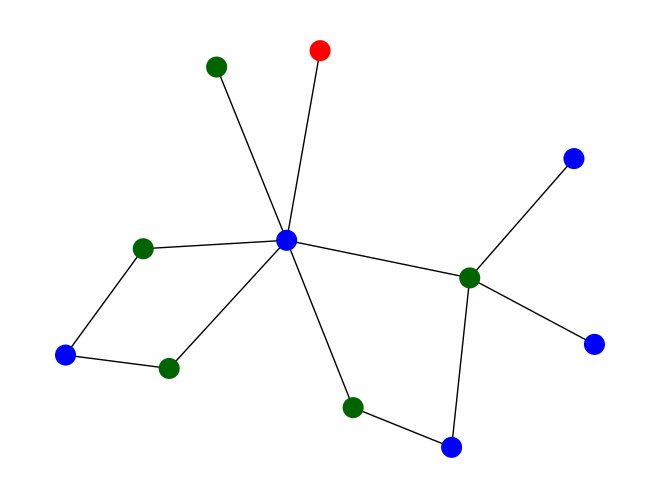

motif


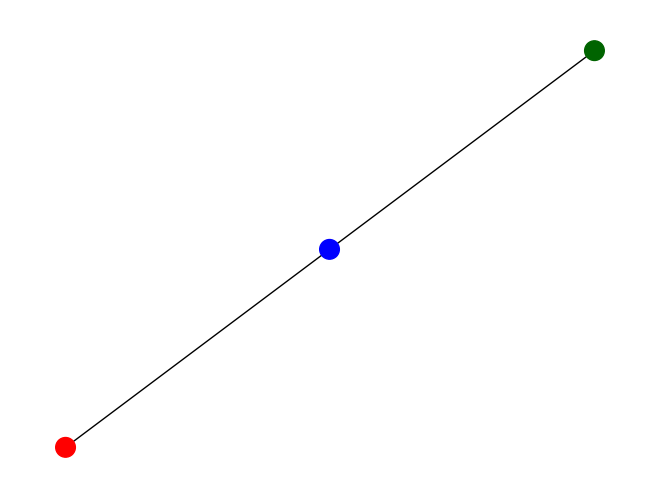

author_node_classes [3, 3]
original graph


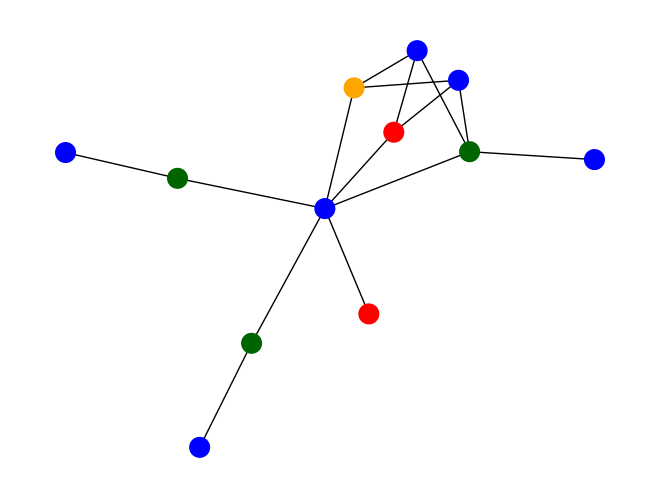

motif


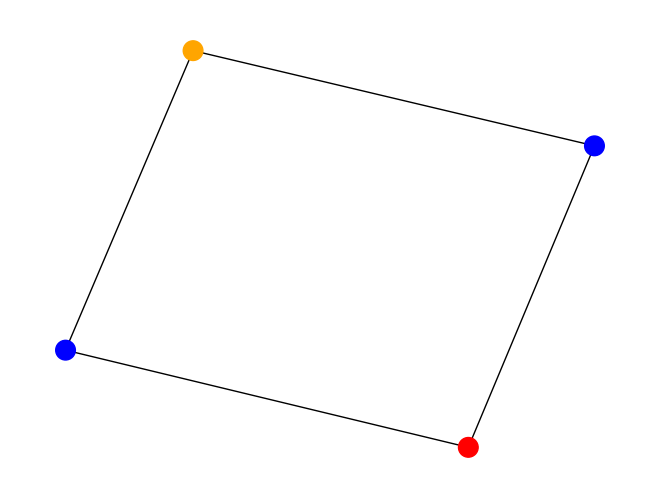

author_node_classes [1]
original graph


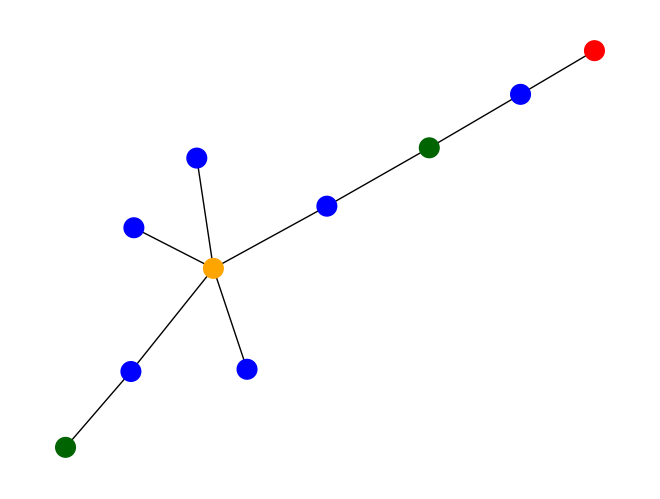

motif


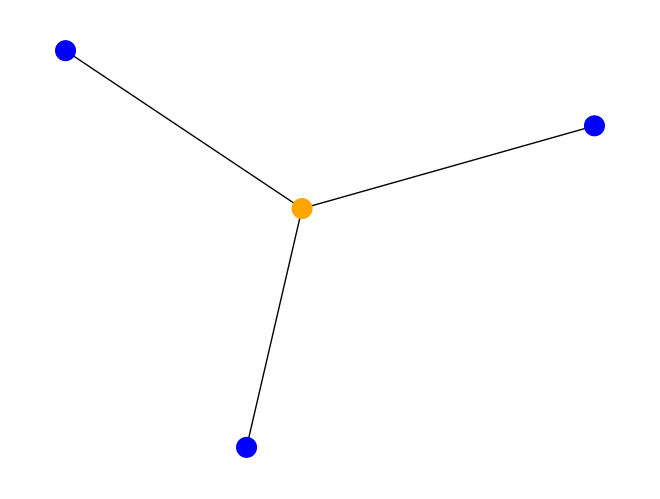

author_node_classes [2, 2]
original graph


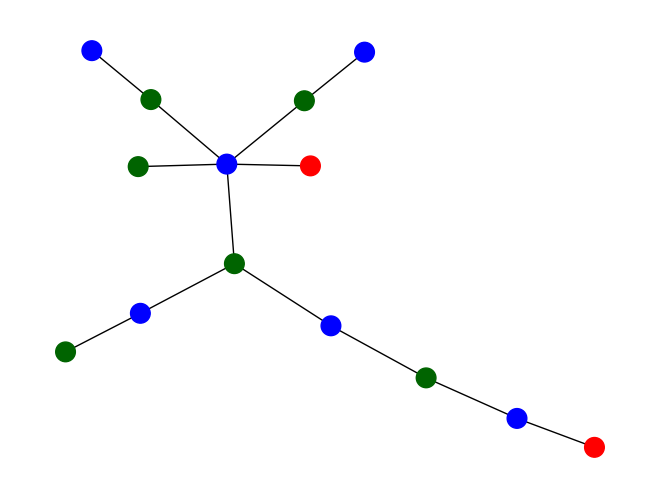

motif


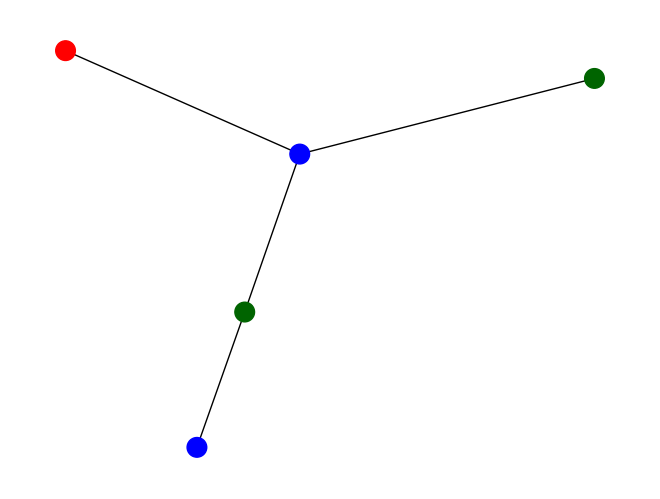

In [6]:
import os
counter = 0  
for file in os.listdir(directory):   
    
    filepath = os.path.join(directory, file)
    G = nx.read_gexf(filepath) 
   
    node_type_list = list(nx.get_node_attributes(G, "type").values())
    node_class_list = list(nx.get_node_attributes(G, "x").values())
    
    indices = [i for i, x in enumerate(node_type_list) if x == author_node_type]
    author_node_classes = [node_class_list[i] for i in indices]
    
    # Filter graphs containing author nodes from a single class
    if len(set(author_node_classes))==1:
        
        # Plot original graph
        if counter % 24 == 0:
            # Print author node class of original graph G
            print('author_node_classes',author_node_classes)
            print('original graph')
            plot_graph(G)

        # Community detection
        list_com= nx.community.louvain_communities(G, seed=123)
        # Extract largest detected community as the motif
        H = G.subgraph(max(list_com, key=len))
    
        #Plot motif
        if counter % 24 == 0:
            print('motif')
            plot_graph(H)
    
        if author_node_classes[0]==0:
            nx.write_gexf(H,path + 'class0/motif_real_dblp_'+str(counter)+'.gexf')
        elif author_node_classes[0]==1:
            nx.write_gexf(H,path + 'class1/motif_real_dblp_'+str(counter)+'.gexf')
        elif author_node_classes[0]==2:
            nx.write_gexf(H,path + 'class2/motif_real_dblp_'+str(counter)+'.gexf')
        elif author_node_classes[0]==3:
            nx.write_gexf(H,path + 'class3/motif_real_dblp_'+str(counter)+'.gexf')    
        
        counter=counter+1   

    